Dataset: https://archive.ics.uci.edu/dataset/145/statlog+heart

In [1]:
import pandas as pd

In [2]:
pdf = pd.read_csv("heart-statlog_csv.csv")
pdf.head()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,present
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,absent
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,present
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,absent
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,absent


In [4]:
pdf.isna().sum()

age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64

In [3]:
pdf["class"].value_counts()

class
absent     150
present    120
Name: count, dtype: int64

In [5]:
X = pdf.drop(columns = ["class"])
y = pdf["class"]

In [6]:
X.head()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


In [7]:
y.head()

0    present
1     absent
2    present
3     absent
4     absent
Name: class, dtype: object

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216, 13), (54, 13), (216,), (54,))

In [29]:
y_train.value_counts()

class
absent     117
present     99
Name: count, dtype: int64

In [13]:
tree = DecisionTreeClassifier()
tree

DecisionTreeClassifier()

In [14]:
tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [15]:
X_train.head(1)

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
115,49,0,2,134,271,0,0,162,0,0.0,2,0,3


In [16]:
y_train.head(1)

115    absent
Name: class, dtype: object

In [18]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

In [19]:
accuracy_score(y_train, y_train_pred)

1.0

In [20]:
accuracy_score(y_test, y_test_pred)

0.7222222222222222

In [22]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

      absent       1.00      1.00      1.00       117
     present       1.00      1.00      1.00        99

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [23]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

      absent       0.82      0.70      0.75        33
     present       0.62      0.76      0.68        21

    accuracy                           0.72        54
   macro avg       0.72      0.73      0.72        54
weighted avg       0.74      0.72      0.73        54



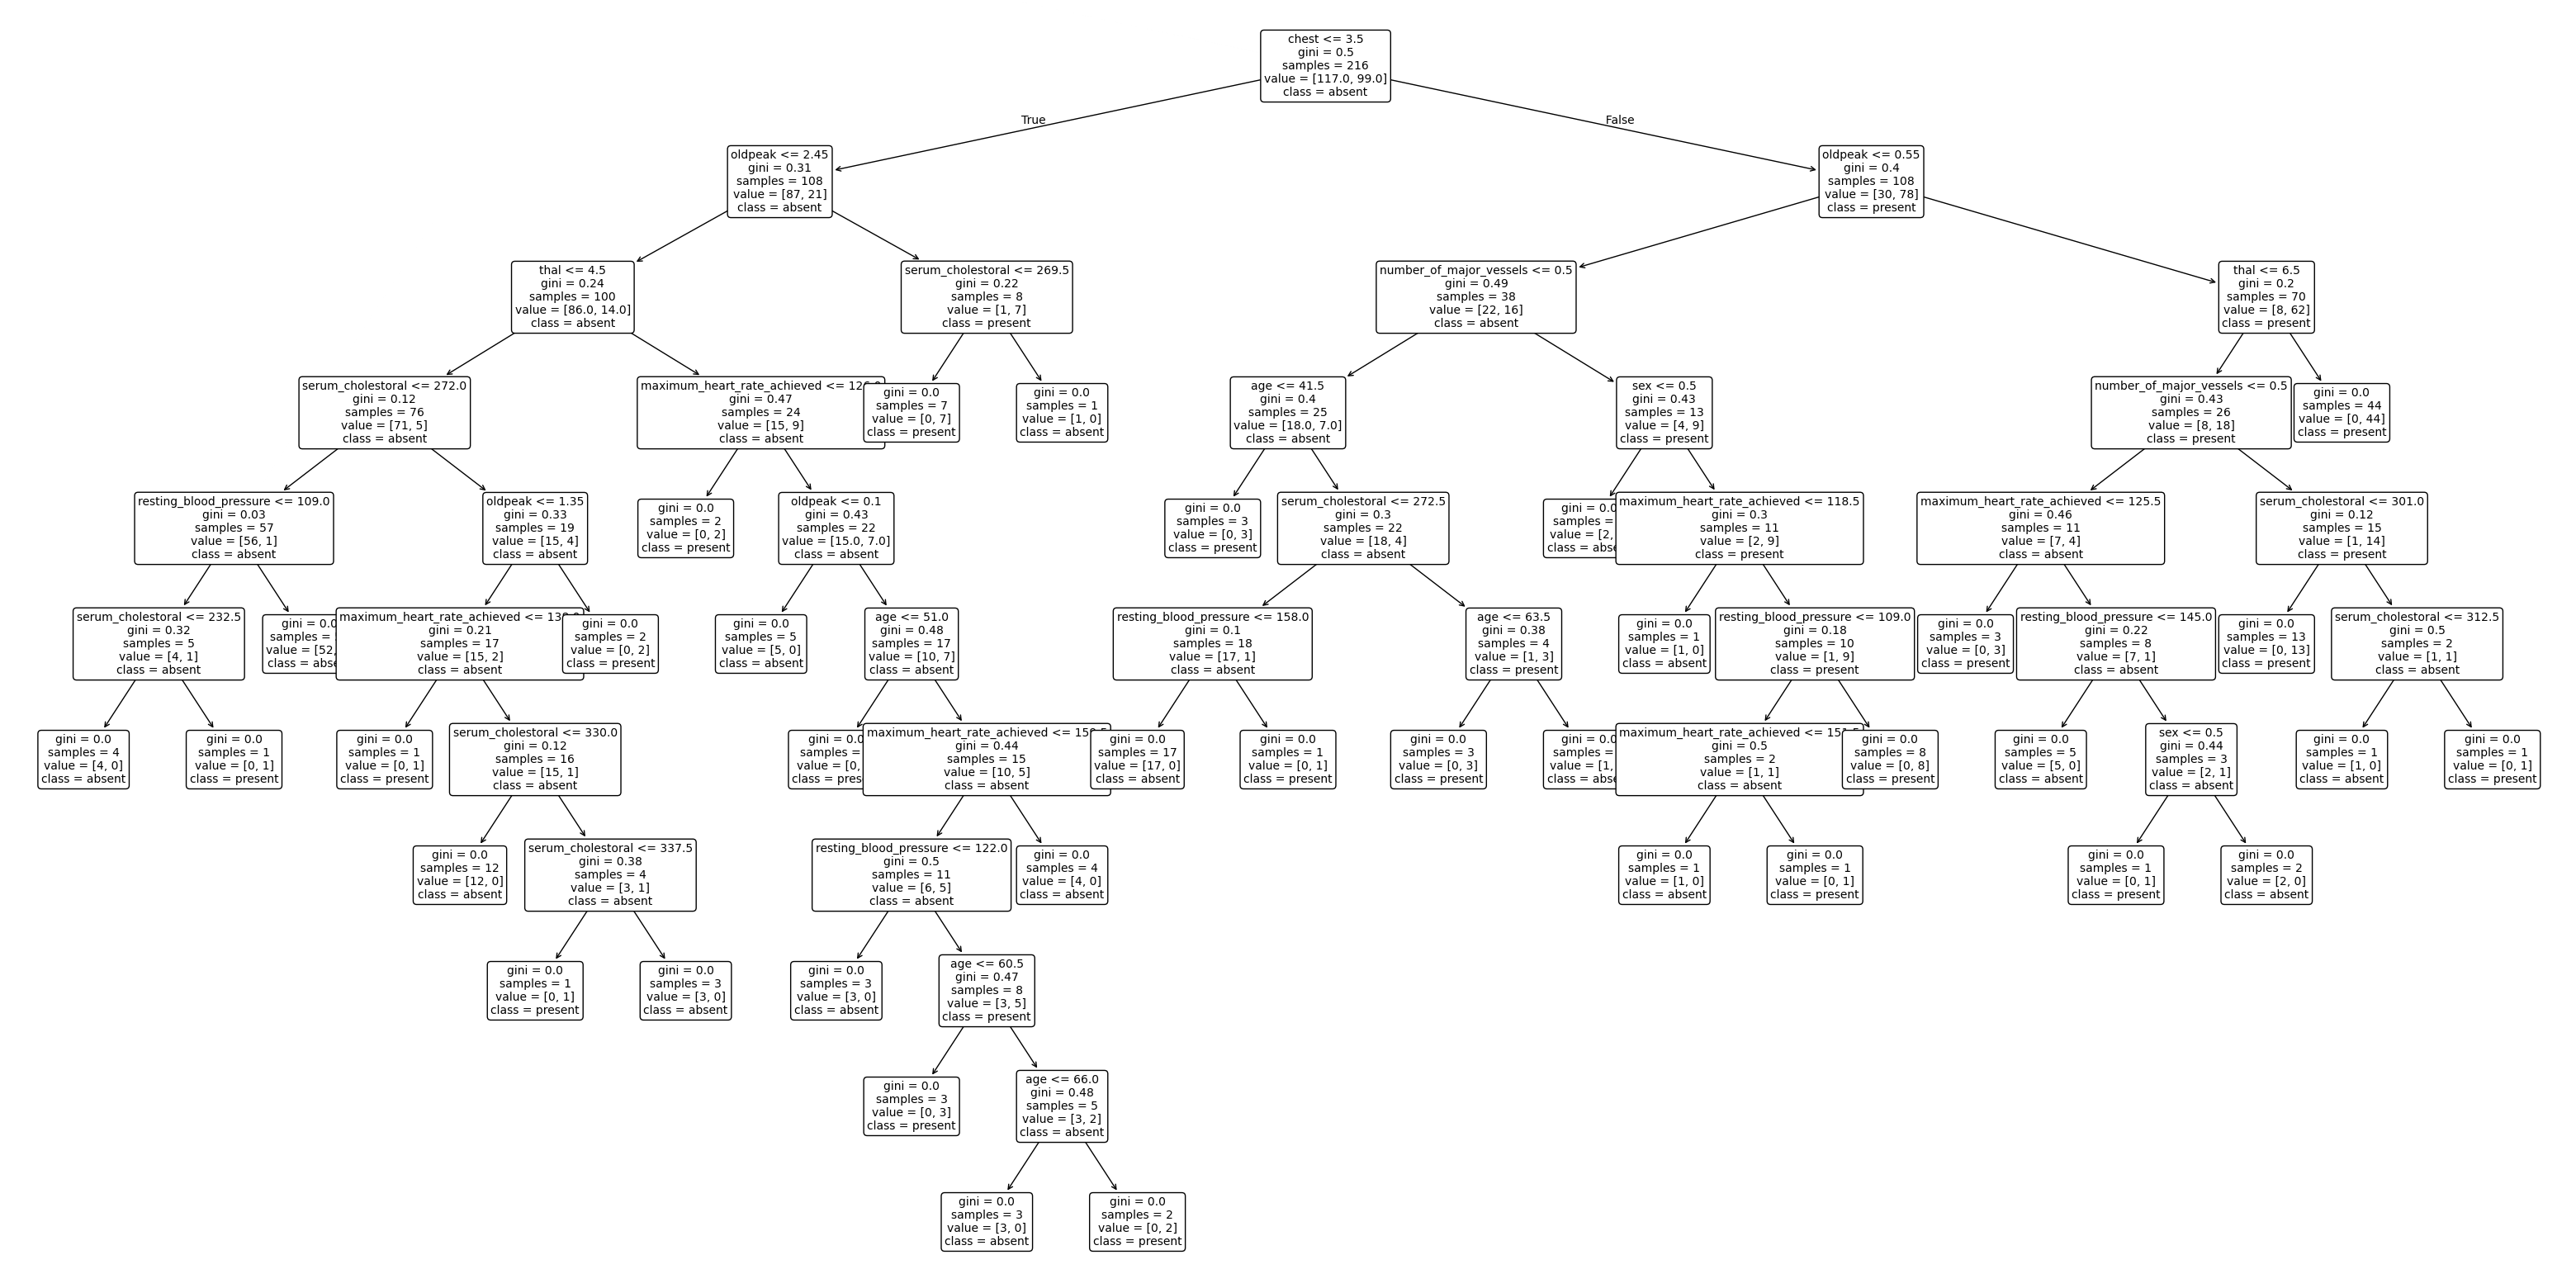

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# feature_names=None, 
# class_names=None, 
# label='all', 
# filled=False, 
# impurity=True, 
# node_ids=False, 
# proportion=False, 
# rounded=False, precision=3, ax=None, fontsize=None

plt.figure(figsize = (40,20))
_  = plot_tree(tree, rounded=True, fontsize=10, precision=2, feature_names=X_train.columns, class_names=["absent", "present"])

In [31]:
tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

### second attempt

              precision    recall  f1-score   support

      absent       0.87      0.94      0.90       117
     present       0.92      0.83      0.87        99

    accuracy                           0.89       216
   macro avg       0.89      0.88      0.89       216
weighted avg       0.89      0.89      0.89       216

              precision    recall  f1-score   support

      absent       0.81      0.91      0.86        33
     present       0.82      0.67      0.74        21

    accuracy                           0.81        54
   macro avg       0.82      0.79      0.80        54
weighted avg       0.82      0.81      0.81        54



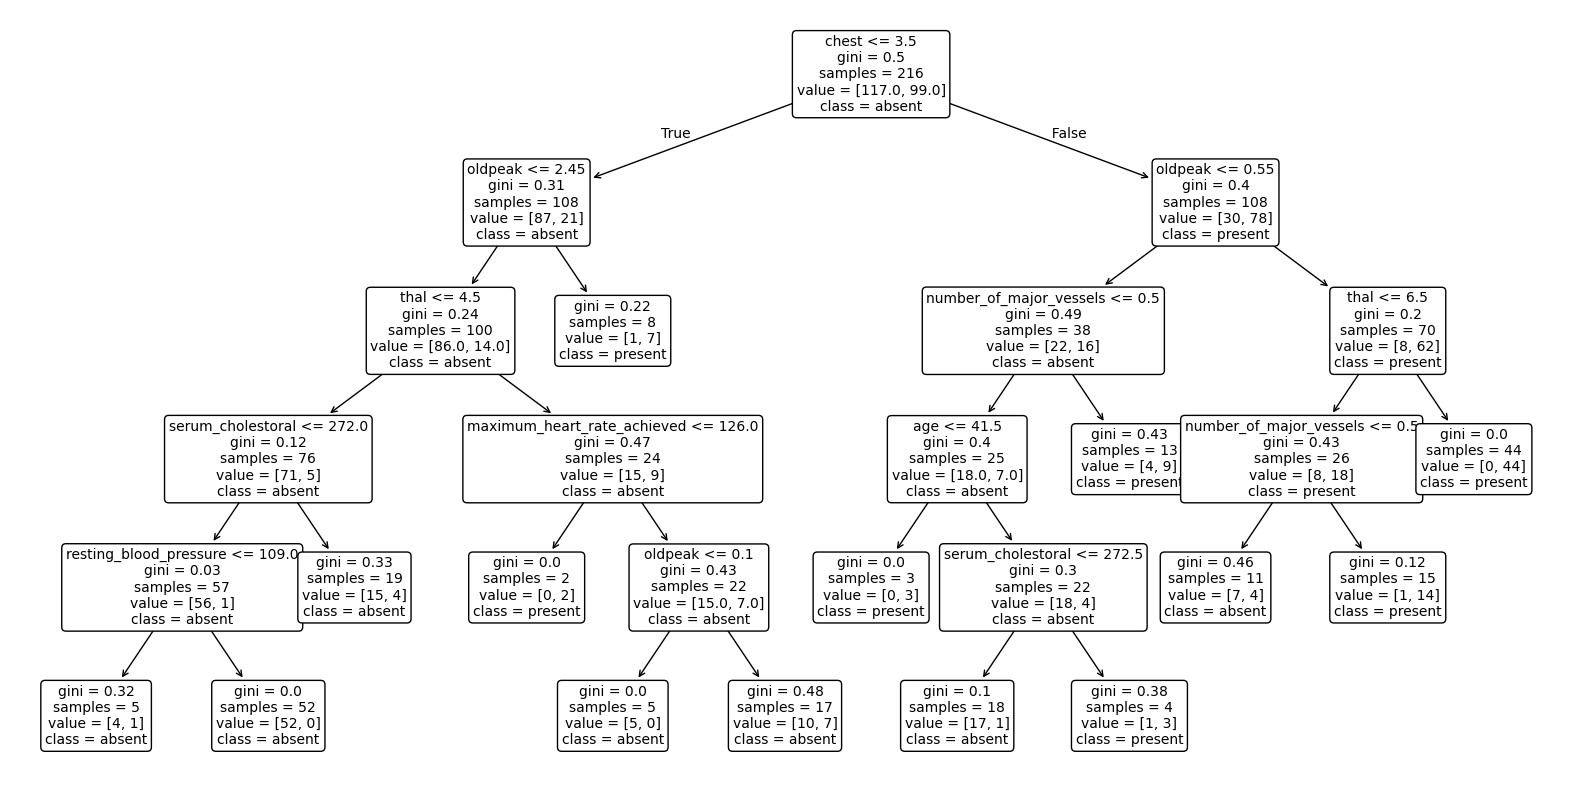

In [34]:
tree = DecisionTreeClassifier(max_depth=5, min_samples_split=0.10)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_test_pred))

plt.figure(figsize = (20,10))
_  = plot_tree(tree, rounded=True, fontsize=10, precision=2, feature_names=X_train.columns, class_names=["absent", "present"])

### grid search

In [68]:
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeClassifier()

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 10, 20],
    "min_samples_split": [0.01, 0.05, 0.10, 0.20],
}

gs = GridSearchCV(estimator=tree, param_grid=param_grid, scoring="accuracy", cv=3)
gs.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 5, 10, 20],
                         'min_samples_split': [0.01, 0.05, 0.1, 0.2]},
             scoring='accuracy')

In [69]:
gs.best_score_

0.7824074074074074

In [73]:
gs.best_params_

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 0.1}

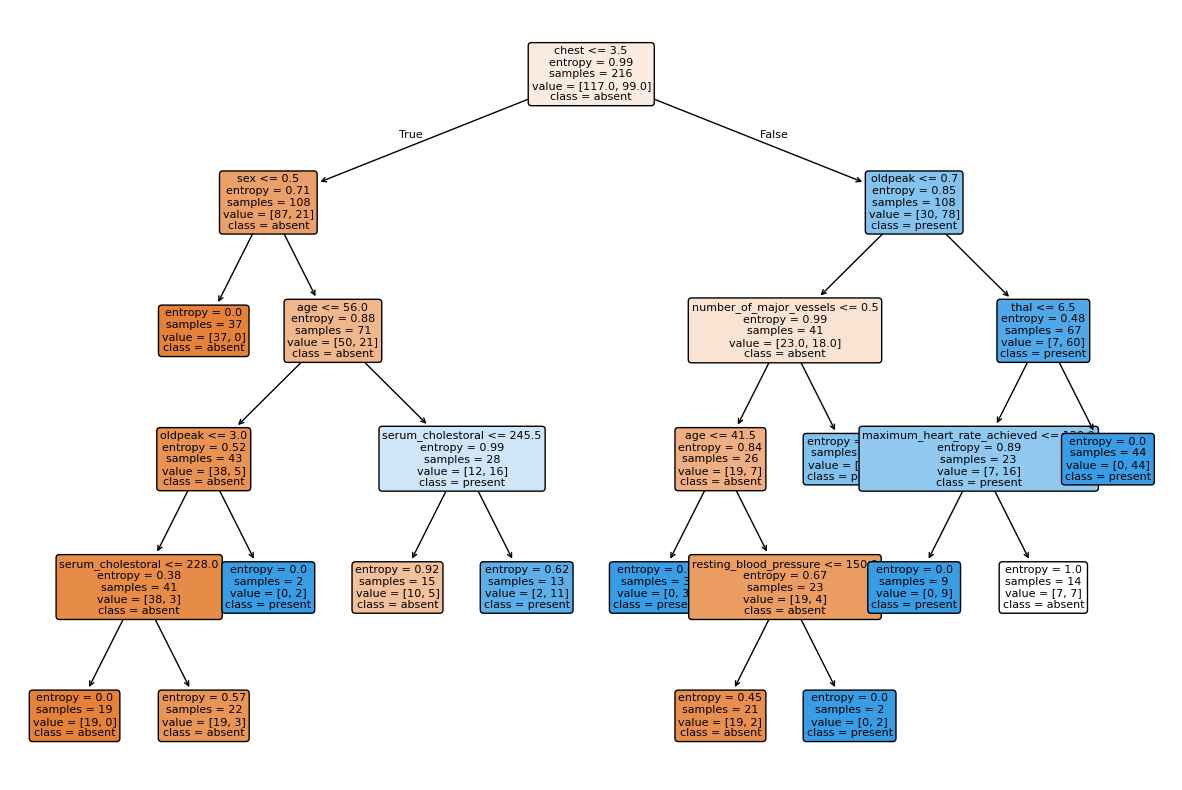

In [72]:
plt.figure(figsize = (15,10))
_ = plot_tree(gs.best_estimator_, rounded=True, 
              fontsize=8, precision=2, feature_names=X_train.columns, class_names=["absent", "present"], filled=True)

In [78]:
feature_importance = pd.DataFrame({"columns": X_train.columns, "importance": gs.best_estimator_.feature_importances_})
feature_importance.sort_values(by="importance", ascending=False)

,columns,importance
2,chest,0.319344
9,oldpeak,0.179764
0,age,0.130454
1,sex,0.100800
12,thal,0.082930
4,serum_cholestoral,0.059579
7,maximum_heart_rate_achieved,0.044264
11,number_of_major_vessels,0.042669
3,resting_blood_pressure,0.040197
5,fasting_blood_sugar,0.000000
